In [13]:
import pandas as pd
df = pd.read_csv(r"C:\Users\uvire\Desktop\Proyectos IA y DS\fraud-detection-system\data\raw\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [19]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

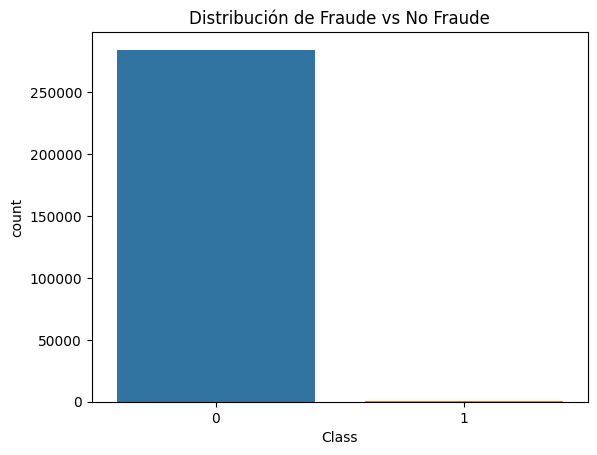

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Distribución de Fraude vs No Fraude")
plt.show

C:\Users\uvire\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<function matplotlib.pyplot.show(close=None, block=None)>

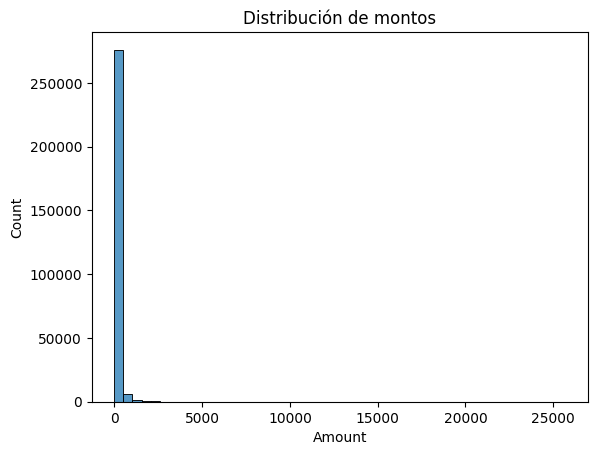

In [27]:
sns.histplot(df['Amount'], bins=50)
plt.title("Distribución de montos")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

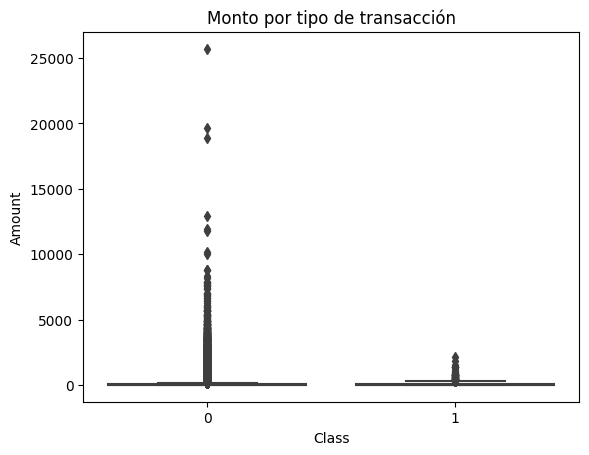

In [31]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Monto por tipo de transacción")
plt.show

## Key Insights

- The dataset is highly imbalanced (fraud cases are rare)
- Fraud detection is a high-risk classification problem
- Transaction amounts show variability between fraud and normal cases
- Accuracy is not a reliable metric for this problem

In [33]:
X=df.drop("Class", axis=1)
y=df["Class"]

In [37]:
from sklearn.model_selection import train_test_split
X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [47]:
from sklearn.ensemble import RandomForestClassifier

model =RandomForestClassifier(
    n_estimators=100, class_weight="balanced",random_state=42)
model.fit(X_train,Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [52]:
y_pred = model.predict(x_test)

In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



<function matplotlib.pyplot.show(close=None, block=None)>

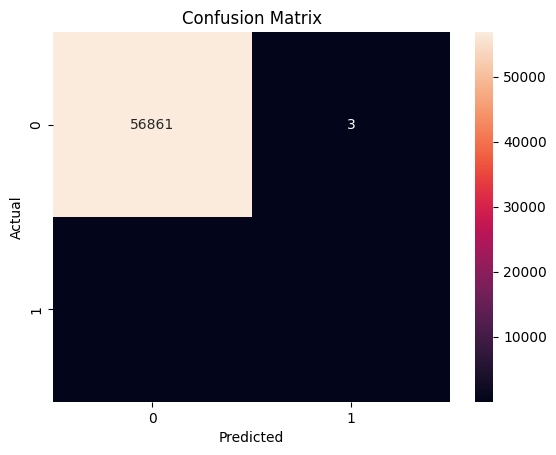

In [56]:
#MATRIZ DE CONFUSIÓN
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show

In [60]:
import joblib

model_package = {
    "model": model,
    "features": X.columns.tolist()
}
joblib.dump(model_package,"C:/Users/uvire/Desktop/Proyectos IA y DS/fraud-detection-system/src/fraud_model.pkl")


['C:/Users/uvire/Desktop/Proyectos IA y DS/fraud-detection-system/src/fraud_model.pkl']

## Model Insights

- The dataset is highly imbalanced, requiring special handling
- Random Forest with class balancing improves fraud detection
- Recall is prioritized over accuracy to minimize undetected fraud
- False negatives represent the highest business risk